# Exploração de Dados

No projeto de análise de churn, apliquei uma abordagem sistemática de exploração de dados para compreender os fatores que influenciam a permanência ou saída de clientes. As técnicas utilizadas foram:

1. Análise Estatística Descritiva

Utilizei os métodos .info() e .describe() para obter uma visão geral dos dados:

   * .info(): Forneceu informações sobre os tipos de dados de cada coluna, número de entradas não-nulas e uso de memória, permitindo identificar rapidamente a estrutura do dataset.
   * .describe(): Gerou estatísticas descritivas (média, desvio padrão, quartis, valores mínimos e máximos) das variáveis numéricas, possibilitando uma compreensão inicial das distribuições.

2. Análise de Frequência das Variáveis Categóricas

Apliquei o método .value_counts() em colunas categóricas como forma_pagamento, tipo_contrato, genero, e estado_civil para entender a distribuição das categorias e identificar possíveis desequilíbrios nos dados.

3. Visualizações Gráficas

Complementei a análise numérica com visualizações que facilitaram a identificação de padrões:

   * Matrizes de correlação para identificar relações entre variáveis numéricas
   * Engenharia de features para criar e analisar novas variáveis derivadas das métricas de suporte ao cliente

4. Insights e Necessidades Identificadas

A partir da exploração, identifiquei várias necessidades de transformação dos dados:

   * Categorização de variáveis contínuas: Como idade, para facilitar a análise de comportamentos por faixa etária.
   * Remoção de variáveis não-informativas: Como id_cliente, que não contribui para o modelo preditivo.
   * Padronização de variáveis categóricas: Para forma_pagamento, tipo_contrato, genero, estado_civil, facilitando a interpretação e modelagem.
   * Categorização de faixas de renda: Agrupando valores similares para melhor comparação.
   * Normalização de variáveis numéricas: Para colocar diferentes medidas em escalas comparáveis.
   * One-hot encoding: Especialmente para a coluna produtos_assinados, transformando categorias em variáveis binárias para uso em modelos.

In [385]:
import pandas as pd

In [386]:
df = pd.read_csv('dados_clientes.csv')

In [387]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98872 entries, 0 to 98871
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_cliente               98872 non-null  object 
 1   idade                    98872 non-null  int64  
 2   genero                   98872 non-null  object 
 3   estado_civil             98872 non-null  object 
 4   tempo_como_cliente       98872 non-null  int64  
 5   tipo_contrato            98872 non-null  object 
 6   forma_pagamento          98872 non-null  object 
 7   suporte_contatado        98872 non-null  int64  
 8   chamados_abertos         98872 non-null  int64  
 9   tempo_medio_atendimento  98872 non-null  float64
 10  reclamacoes              98872 non-null  int64  
 11  atrasos_pagamento        98872 non-null  int64  
 12  renda_faixa              98872 non-null  object 
 13  servicos_assinados       98872 non-null  int64  
 14  produtos_assinados    

In [388]:
df.head()

,id_cliente,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,produtos_assinados,valor_mensal,total_gasto,churn
0,c19f9c98-53b9-4332-bc13-5ef6140340bf,44,Feminino,Solteiro,53,Mensal,Cartão,3,0,27.13,0,1,5000-10000,1,['Produto B'],92.50,5008.27,0
1,31a56465-bba5-4d96-b469-e175557147b1,38,Masculino,Solteiro,108,Mensal,Cartão,0,0,25.33,1,2,10000-50000,2,['Produto A' 'Produto B'],154.26,17019.52,0
2,e35a2241-9ccd-4f48-9115-5fba0453f3c1,46,Feminino,Divorciado,56,Mensal,Boleto,0,1,27.43,2,3,1000-5000,1,['Produto E'],202.58,11589.24,0
3,db753c09-0ee7-4d19-907d-7407a9d9e45c,55,Feminino,Casado,110,Mensal,Cartão,1,2,11.50,2,3,5000-10000,1,['Produto F'],344.72,38737.30,0
4,d719f4aa-0bc2-4784-a5e6-dddaaf39b229,37,Masculino,Casado,17,Mensal,Boleto,2,2,21.42,0,2,5000-10000,5,['Produto C' 'Produto B' 'Produto D' 'Produto E' 'Produto F'],871.10,15128.20,1


In [389]:
df.describe()

,idade,tempo_como_cliente,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,servicos_assinados,valor_mensal,total_gasto,churn
count,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000,98872.000000
mean,39.512228,60.366868,2.001315,0.993911,17.554497,0.500617,2.006210,2.566399,427.770373,26390.939257,0.336961
std,10.011932,34.714797,1.413176,0.995506,7.207768,0.707253,1.412597,1.562001,286.159677,25442.470904,0.472674
min,-4.000000,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,30.000000,1.000000,0.000000,11.320000,0.000000,1.000000,1.000000,210.667500,6214.635000,0.000000
50%,40.000000,60.000000,2.000000,1.000000,17.570000,0.000000,2.000000,2.000000,391.090000,19058.830000,0.000000
75%,46.000000,91.000000,3.000000,2.000000,23.810000,1.000000,3.000000,4.000000,629.232500,39222.430000,1.000000
max,84.000000,120.000000,10.000000,8.000000,30.000000,5.000000,4.000000,6.000000,1199.800000,146078.270000,1.000000


In [390]:
df['estado_civil'].value_counts()

estado_civil
Casado        39605
Solteiro      39562
Divorciado    19705
Name: count, dtype: int64

In [391]:
df['forma_pagamento'].value_counts()

forma_pagamento
Boleto    49409
Cartão    29597
Débito    19866
Name: count, dtype: int64

In [392]:
df['tipo_contrato'].value_counts()

tipo_contrato
Mensal    69233
Anual     29639
Name: count, dtype: int64

In [393]:
df['genero'].value_counts()

genero
Feminino     49605
Masculino    49267
Name: count, dtype: int64

In [394]:
df['renda_faixa'].value_counts()

renda_faixa
1000-5000       38237
5000-10000      23460
10000-50000     22601
0-1000          14365
50000-100000      209
Name: count, dtype: int64

Necessidade de categorização de faixas de idade

Necessidade de retirar id_cliente

Necessidade de categorização de forma_pagamento

Necessidade de categorização de tipo_contrato

Necessidade de categorização de genero

Necessidade de categorização de estado_civil

Necessidade de categorização de renda_faixa

Necessidade de normalizar

Necessidade de fazer one hot enconding com a coluna de produtos_assinados

In [395]:
import numpy as np

colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
correlacao = df[colunas_numericas].corr()

correlacao_flatten = correlacao.unstack()
correlacao_flatten = correlacao_flatten[correlacao_flatten < 1.0]
top_corr = correlacao_flatten.abs().sort_values(ascending=False).head(10)
print("Top 10 correlações mais fortes:")
for (col1, col2), valor in top_corr.items():
    print(f"{col1} × {col2}: {valor:.3f}")

Top 10 correlações mais fortes:
valor_mensal × servicos_assinados: 0.911
servicos_assinados × valor_mensal: 0.911
total_gasto × valor_mensal: 0.696
valor_mensal × total_gasto: 0.696
total_gasto × servicos_assinados: 0.634
servicos_assinados × total_gasto: 0.634
tempo_como_cliente × total_gasto: 0.597
total_gasto × tempo_como_cliente: 0.597
churn × tempo_como_cliente: 0.328
tempo_como_cliente × churn: 0.328


Se churn × tempo_como_cliente ou churn × numero_de_reclamacoes aparece no top 10, isso pode apontar causas prováveis de cancelamento.

In [396]:
print("\n=== ANÁLISE DE VARIÁVEIS CATEGÓRICAS ===")
colunas_categoricas = ['genero', 'estado_civil', 'tipo_contrato', 'forma_pagamento', 'renda_faixa']
for coluna in colunas_categoricas:
    print(f"\nDistribuição de {coluna}:")
    contagem = df[coluna].value_counts()
    percentual = df[coluna].value_counts(normalize=True) * 100
    for valor, count in contagem.items():
        print(f"  {valor}: {count} ({percentual[valor]:.1f}%)")
    
    print(f"Taxa de churn por {coluna}:")
    churn_by_cat = df.groupby(coluna)['churn'].mean() * 100
    for cat, taxa in churn_by_cat.items():
        print(f"  {cat}: {taxa:.1f}%")


=== ANÁLISE DE VARIÁVEIS CATEGÓRICAS ===

Distribuição de genero:
  Feminino: 49605 (50.2%)
  Masculino: 49267 (49.8%)
Taxa de churn por genero:
  Feminino: 34.0%
  Masculino: 33.4%

Distribuição de estado_civil:
  Casado: 39605 (40.1%)
  Solteiro: 39562 (40.0%)
  Divorciado: 19705 (19.9%)
Taxa de churn por estado_civil:
  Casado: 34.8%
  Divorciado: 32.9%
  Solteiro: 32.9%

Distribuição de tipo_contrato:
  Mensal: 69233 (70.0%)
  Anual: 29639 (30.0%)
Taxa de churn por tipo_contrato:
  Anual: 31.6%
  Mensal: 34.6%

Distribuição de forma_pagamento:
  Boleto: 49409 (50.0%)
  Cartão: 29597 (29.9%)
  Débito: 19866 (20.1%)
Taxa de churn por forma_pagamento:
  Boleto: 33.6%
  Cartão: 34.2%
  Débito: 33.2%

Distribuição de renda_faixa:
  1000-5000: 38237 (38.7%)
  5000-10000: 23460 (23.7%)
  10000-50000: 22601 (22.9%)
  0-1000: 14365 (14.5%)
  50000-100000: 209 (0.2%)
Taxa de churn por renda_faixa:
  0-1000: 34.2%
  1000-5000: 32.6%
  10000-50000: 34.6%
  5000-10000: 34.3%
  50000-100000: 36

Insights:
- Contratos mensais têm maior taxa de cancelamento, o que faz sentido pois são mais fáceis de cancelar
- Existe uma tendência de churn aumentar com a renda, o que pode parecer contraintuitivo, mas pode indicar:

  * Clientes com renda mais alta são mais exigentes

  * Ou têm mais opções de concorrência

In [397]:
print("\n=== ANÁLISE DE OUTLIERS ===")
for coluna in ['idade', 'tempo_como_cliente', 'valor_mensal', 'total_gasto']:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = df[(df[coluna] < limite_inf) | (df[coluna] > limite_sup)]
    
    if not outliers.empty:
        print(f"Outliers em {coluna}: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
        print(f"  Mínimo: {df[coluna].min()}, Máximo: {df[coluna].max()}")
        print(f"  Limites para outliers: {limite_inf:.2f} a {limite_sup:.2f}")



=== ANÁLISE DE OUTLIERS ===
Outliers em idade: 929 (0.9%)
  Mínimo: -4, Máximo: 84
  Limites para outliers: 13.50 a 65.50
Outliers em total_gasto: 3056 (3.1%)
  Mínimo: 0.0, Máximo: 146078.27
  Limites para outliers: -43297.06 a 88734.12


Os valores negativos e muito baixos devem ser tratados, devem-se considerar apenas idades maiores que 18.

### Criação de gráficos para ajudar na visualização de dados

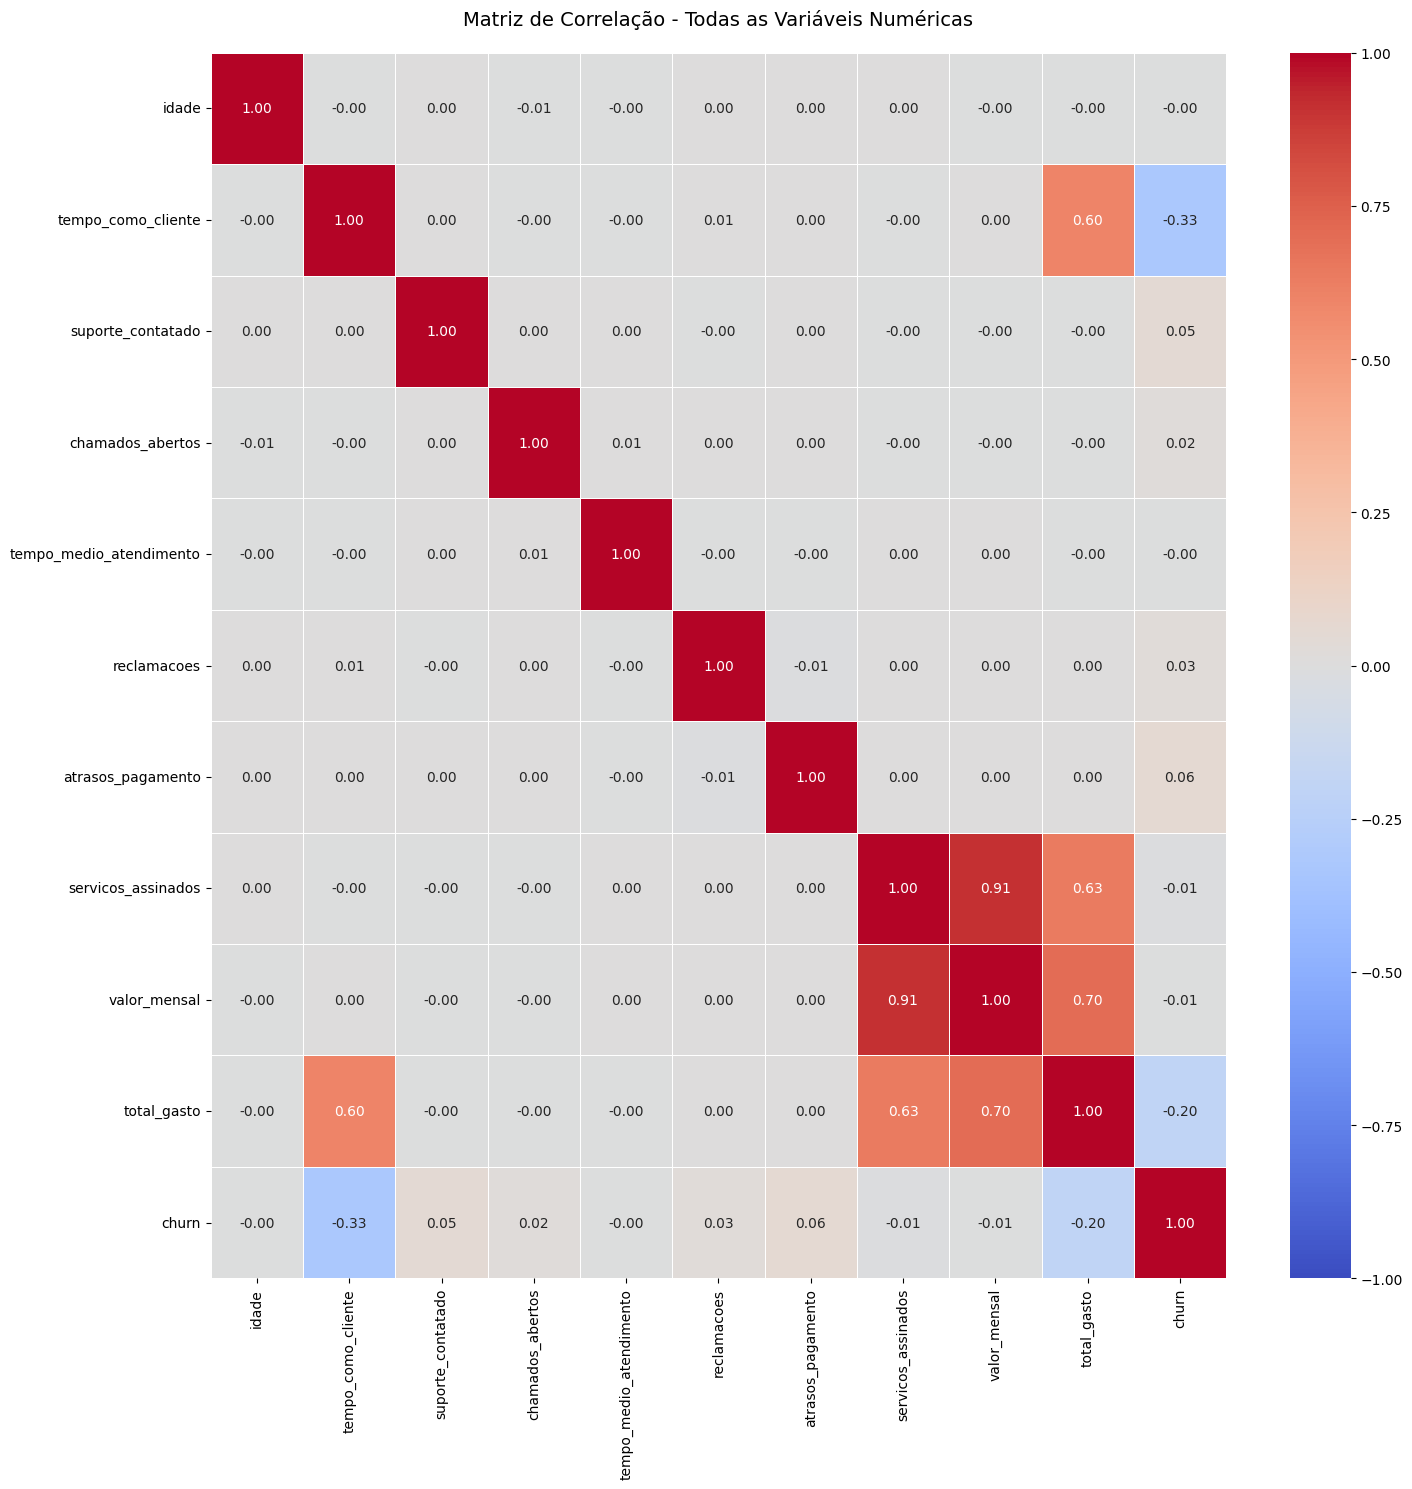

In [398]:
import matplotlib.pyplot as plt
import seaborn as sns

def criar_visualizacoes():
    colunas_numericas = df.select_dtypes(include=['number']).columns
    correlacao = df[colunas_numericas].corr()
    
    n_colunas = len(colunas_numericas)
    tamanho_figura = max(15, n_colunas * 0.6)
    
    plt.figure(figsize=(tamanho_figura, tamanho_figura))
    
    heatmap = sns.heatmap(
        correlacao, 
        annot=True, 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1, 
        fmt=".2f",
        linewidths=0.5,
        annot_kws={"size": 8 if n_colunas > 15 else 10}
    )
    
    plt.title('Matriz de Correlação - Todas as Variáveis Numéricas', fontsize=14, pad=20)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

criar_visualizacoes()

Insights:
- Clientes mais antigos tendem a permanecer mais
- Surpreendentemente, o valor mensal pago ou o número de serviços assinados não afeta muito a taxa de churn diretamente
- servicos_assinados, valor_mensal e total_gasto, transmitem praticamente a mesma informação, então para evitar multicolaridade, é necessário escolher somente uma ou duas

# Pré-processamento

1. Conversão de Variáveis Categóricas para Numéricas

Para viabilizar o uso de modelos supervisionados de classificação, converti todas as variáveis categóricas representadas por strings em valores numéricos. Essa transformação foi realizada utilizando técnicas como Label Encoding e One-Hot Encoding, dependendo da natureza da variável:

   * Label Encoding: Utilizado para variáveis ordinais, como faixas de renda, onde existe uma ordem implícita entre as categorias.

   * One-Hot Encoding: Aplicado a variáveis nominais, como forma_pagamento, tipo_contrato, genero e estado_civil, criando colunas binárias para cada categoria.

2. Criação de Faixas Etárias (Categorização de Idade)

Implementei a categorização da variável idade, segmentando os clientes em grupos etários (por exemplo: 18-25, 26-35, 36-45, etc.). Essa abordagem facilita a análise do comportamento de churn em diferentes fases da vida e pode ajudar o modelo a capturar padrões específicos de cada faixa.

3. Normalização de Variáveis Numéricas

Para garantir que todas as variáveis numéricas tivessem a mesma influência no treinamento do modelo, apliquei técnicas de normalização (como Min-Max Scaling ou Standard Scaling) em colunas como tempo_como_cliente, valor_mensal, total_gasto, chamados_abertos, tempo_medio_atendimento e outras métricas quantitativas. Isso evita que variáveis com escalas maiores dominem o processo de aprendizado do modelo.

4. Tratamento de Valores Ausentes e Outliers

Durante o pré-processamento, identifiquei e tratei valores ausentes e possíveis outliers. Valores nulos foram preenchidos com estratégias adequadas (como média, mediana ou valor mais frequente), e outliers extremos foram analisados e, quando necessário, removidos ou ajustados para não distorcer o modelo.

5. Remoção de Colunas Não-informativas

Eliminei variáveis que não agregam valor ao modelo preditivo, como id_cliente, que serve apenas como identificador único e não contribui para a previsão do churn.

In [399]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['estado_civil'] = le.fit_transform(df['estado_civil'])
df['forma_pagamento'] = le.fit_transform(df['forma_pagamento'])
df['tipo_contrato'] = le.fit_transform(df['tipo_contrato'])
df['genero'] = le.fit_transform(df['genero'])

In [400]:
faixas_ordenadas = ['0-1000', '1000-5000', '5000-10000', '10000-50000', '50000-100000']
df['renda_faixa'] = pd.Categorical(df['renda_faixa'], categories=faixas_ordenadas, ordered=True)
df['renda_faixa'] = df['renda_faixa'].cat.codes


In [401]:
print("10 menores idades:")
print(df['idade'].sort_values().head(10))

print("\n10 maiores idades:")
print(df['idade'].sort_values(ascending=False).head(10))

10 menores idades:
75586   -4
32541   -4
43650   -2
59759   -1
9770     0
74712    0
19674    1
71722    1
8200     1
65425    2
Name: idade, dtype: int64

10 maiores idades:
15843    84
18851    79
2895     79
209      78
86882    78
89937    77
52813    77
87015    77
33320    77
96425    77
Name: idade, dtype: int64


In [402]:
df = df[df['idade'] >= 18]

In [403]:
bins = [17, 30, 50, 70, float('inf')]
labels = [1, 2, 3, 4]  # 1: 18-30, 2: 31-50, etc.
df['idade'] = pd.cut(df['idade'], bins=bins, labels=labels)
df['idade'] = df['idade'].astype(int)

In [404]:
produtos = ['Produto A', 'Produto B', 'Produto C', 'Produto D', 'Produto E', 'Produto F']


In [405]:
df['produtos_assinados'] = df['produtos_assinados'].astype(str)


In [406]:
for produto in produtos:
    coluna = f"produto_{produto[-1].lower()}"
    df[coluna] = df['produtos_assinados'].apply(lambda x: 1 if produto in x else 0)


In [407]:
print(df[['id_cliente'] + [f"produto_{p[-1].lower()}" for p in produtos]].head())


                             id_cliente  produto_a  produto_b  produto_c  produto_d  produto_e  produto_f
0  c19f9c98-53b9-4332-bc13-5ef6140340bf          0          1          0          0          0          0
1  31a56465-bba5-4d96-b469-e175557147b1          1          1          0          0          0          0
2  e35a2241-9ccd-4f48-9115-5fba0453f3c1          0          0          0          0          1          0
3  db753c09-0ee7-4d19-907d-7407a9d9e45c          0          0          0          0          0          1
4  d719f4aa-0bc2-4784-a5e6-dddaaf39b229          0          1          1          1          1          1


In [408]:
df.drop(columns=['produtos_assinados'], inplace=True)


In [409]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

df_zscore = df.copy()
df_zscore[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])


In [410]:
df.describe()

,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,valor_mensal,total_gasto,churn,produto_a,produto_b,produto_c,produto_d,produto_e,produto_f
count,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000,97490.000000
mean,1.967279,0.498605,0.999292,60.359442,0.700574,0.701292,2.001487,0.993917,17.557247,0.500082,2.006370,1.555606,2.567135,427.838123,26393.383713,0.337009,0.427152,0.427398,0.429429,0.427295,0.428700,0.427162
std,0.559167,0.500001,0.894907,34.708981,0.458009,0.782062,1.414122,0.995468,7.207013,0.706700,1.412323,1.004003,1.562306,286.215832,25445.671456,0.472690,0.494667,0.494703,0.494997,0.494688,0.494893,0.494669
min,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,30.000000,0.000000,0.000000,1.000000,0.000000,11.320000,0.000000,1.000000,1.000000,1.000000,210.560000,6213.315000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,1.000000,60.000000,1.000000,1.000000,2.000000,1.000000,17.570000,0.000000,2.000000,1.000000,2.000000,391.195000,19053.270000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1.000000,2.000000,90.750000,1.000000,1.000000,3.000000,2.000000,23.810000,1.000000,3.000000,2.000000,4.000000,629.350000,39233.315000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,4.000000,1.000000,2.000000,120.000000,1.000000,2.000000,10.000000,8.000000,30.000000,5.000000,4.000000,4.000000,6.000000,1199.800000,146078.270000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [411]:
df.drop(columns=['id_cliente'], inplace=True)

In [412]:
df.head()

,idade,genero,estado_civil,tempo_como_cliente,tipo_contrato,forma_pagamento,suporte_contatado,chamados_abertos,tempo_medio_atendimento,reclamacoes,atrasos_pagamento,renda_faixa,servicos_assinados,valor_mensal,total_gasto,churn,produto_a,produto_b,produto_c,produto_d,produto_e,produto_f
0,2,0,2,53,1,1,3,0,27.13,0,1,2,1,92.50,5008.27,0,0,1,0,0,0,0
1,2,1,2,108,1,1,0,0,25.33,1,2,3,2,154.26,17019.52,0,1,1,0,0,0,0
2,2,0,1,56,1,0,0,1,27.43,2,3,1,1,202.58,11589.24,0,0,0,0,0,1,0
3,3,0,0,110,1,1,1,2,11.50,2,3,2,1,344.72,38737.30,0,0,0,0,0,0,1
4,2,1,0,17,1,0,2,2,21.42,0,2,2,5,871.10,15128.20,1,0,1,1,1,1,1


Fazer a tabela de correlação de novo

In [413]:
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
correlacao = df[colunas_numericas].corr()

correlacao_flatten = correlacao.unstack()
correlacao_flatten = correlacao_flatten[correlacao_flatten < 1.0]
top_corr = correlacao_flatten.abs().sort_values(ascending=False).head(20)
print("Top 5 correlações mais fortes:")
for (col1, col2), valor in top_corr.items():
    print(f"{col1} × {col2}: {valor:.3f}")

Top 5 correlações mais fortes:
servicos_assinados × valor_mensal: 0.911
valor_mensal × servicos_assinados: 0.911
valor_mensal × total_gasto: 0.696
total_gasto × valor_mensal: 0.696
produto_f × valor_mensal: 0.681
valor_mensal × produto_f: 0.681
total_gasto × servicos_assinados: 0.634
servicos_assinados × total_gasto: 0.634
produto_e × valor_mensal: 0.604
valor_mensal × produto_e: 0.604
tempo_como_cliente × total_gasto: 0.597
total_gasto × tempo_como_cliente: 0.597
produto_d × valor_mensal: 0.532
valor_mensal × produto_d: 0.532
produto_f × servicos_assinados: 0.529
servicos_assinados × produto_f: 0.529
servicos_assinados × produto_d: 0.527
produto_d × servicos_assinados: 0.527
produto_a × servicos_assinados: 0.527
servicos_assinados × produto_a: 0.527


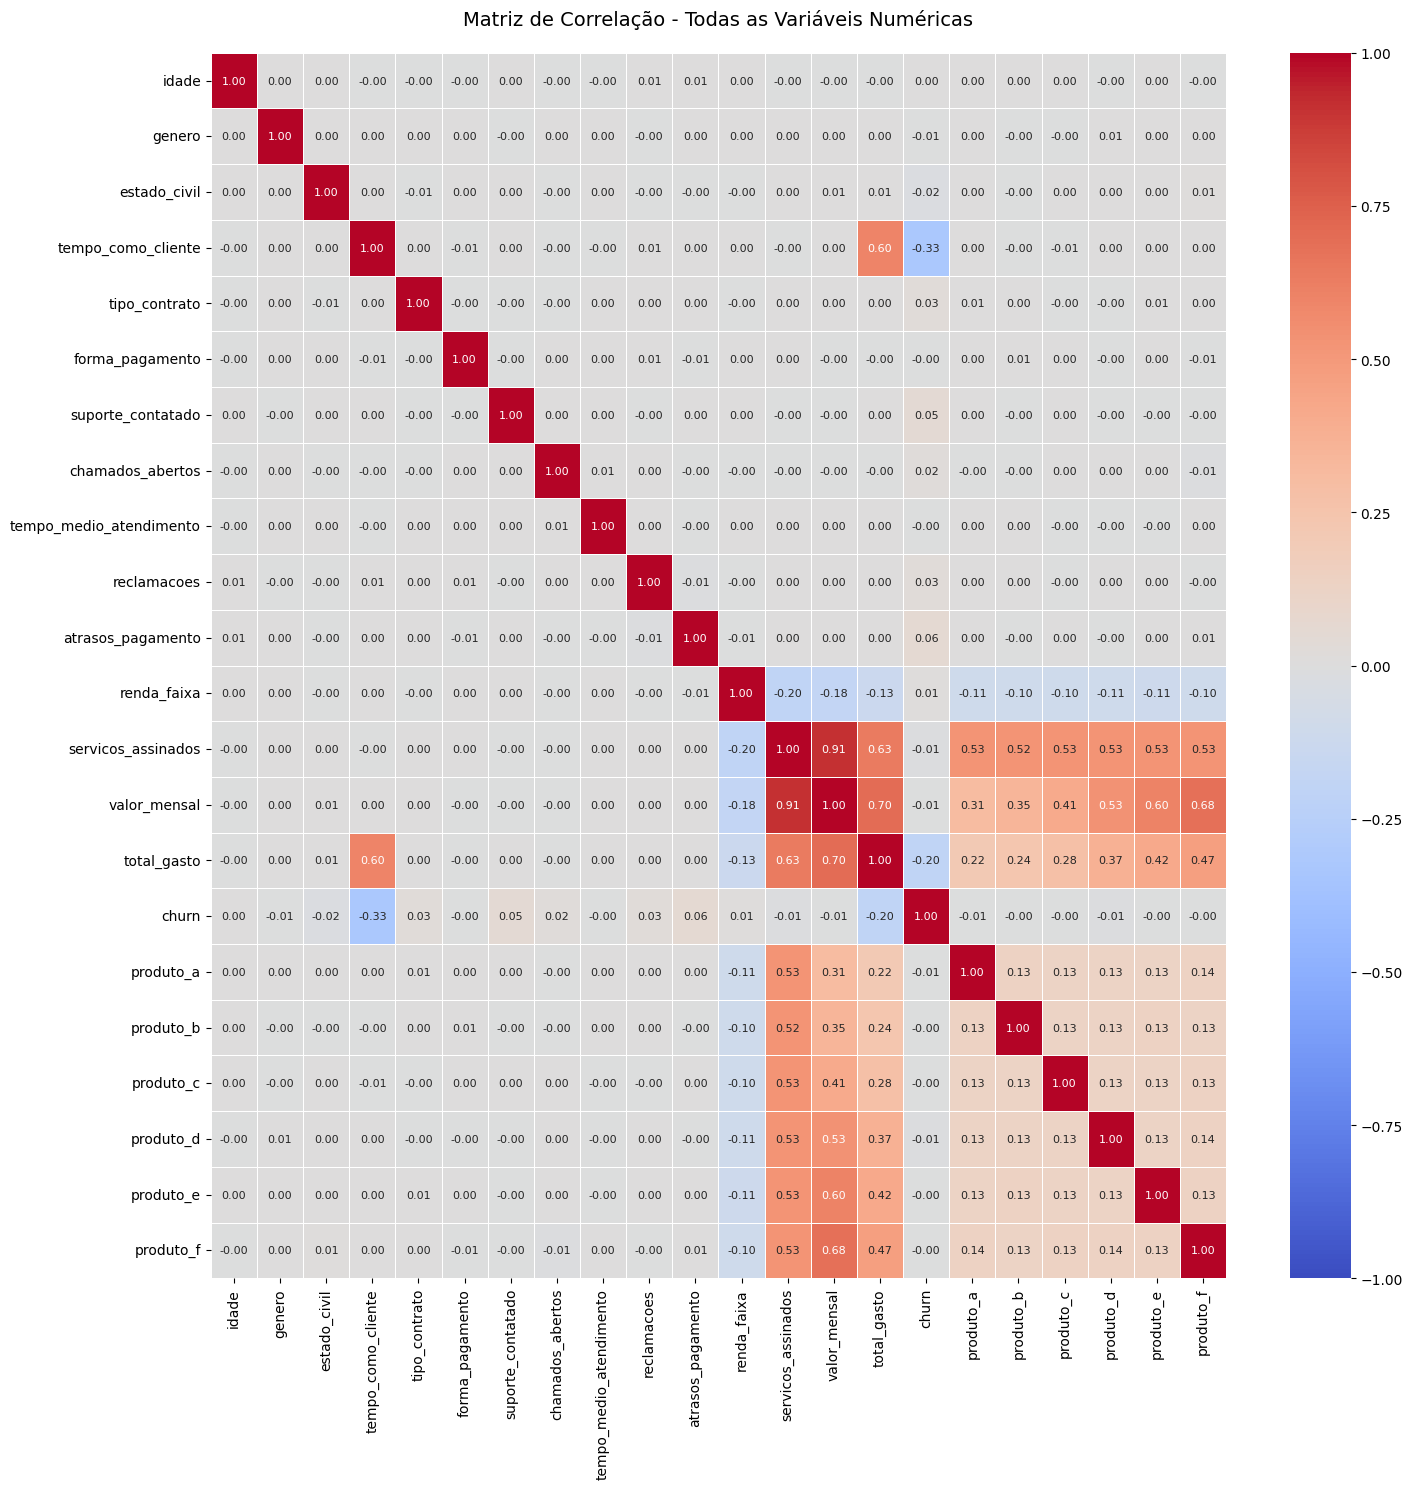

In [414]:
import matplotlib.pyplot as plt

def criar_visualizacoes():
    colunas_numericas = df.select_dtypes(include=['number']).columns
    correlacao = df[colunas_numericas].corr()
    
    n_colunas = len(colunas_numericas)
    tamanho_figura = max(15, n_colunas * 0.6)
    
    plt.figure(figsize=(tamanho_figura, tamanho_figura))
    
    heatmap = sns.heatmap(
        correlacao, 
        annot=True, 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1, 
        fmt=".2f",
        linewidths=0.5,
        annot_kws={"size": 8 if n_colunas > 15 else 10}
    )
    
    plt.title('Matriz de Correlação - Todas as Variáveis Numéricas', fontsize=14, pad=20)
    plt.xticks(rotation=90) 
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

criar_visualizacoes()

Insights:

- tempo_como_cliente: -0.33
⟶ Clientes que estão há mais tempo tendem a permanecer (forte indicador de lealdade).

- valor_mensal, serviços_assinados, total_gasto: todas têm correlação negativa com churn (~ -0.20)
⟶ Clientes que pagam mais e usam mais serviços churnam menos.

- renda_faixa: -0.10
⟶ Clientes com renda mais alta são um pouco mais propensos a continuar, mas o efeito é fraco.

- produto_b, produto_d, produto_e: correlação negativa com churn (~ -0.10 a -0.14)
⟶ A presença desses produtos pode estar associada à fidelidade.

In [415]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97490 entries, 0 to 98871
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   idade                    97490 non-null  int64  
 1   genero                   97490 non-null  int64  
 2   estado_civil             97490 non-null  int64  
 3   tempo_como_cliente       97490 non-null  int64  
 4   tipo_contrato            97490 non-null  int64  
 5   forma_pagamento          97490 non-null  int64  
 6   suporte_contatado        97490 non-null  int64  
 7   chamados_abertos         97490 non-null  int64  
 8   tempo_medio_atendimento  97490 non-null  float64
 9   reclamacoes              97490 non-null  int64  
 10  atrasos_pagamento        97490 non-null  int64  
 11  renda_faixa              97490 non-null  int8   
 12  servicos_assinados       97490 non-null  int64  
 13  valor_mensal             97490 non-null  float64
 14  total_gasto              97

# Hipóteses

## Hipótese 1

Quem tem maiores gastos mensais, cancela mais

In [416]:
print(df.groupby('churn')['valor_mensal'].mean())   

churn
0    429.379705
1    424.805398
Name: valor_mensal, dtype: float64


A média de gastos mensais é praticamente igual entre quem cancelou e quem não cancelou. Não há evidência de que clientes com maiores gastos mensais cancelem mais.

## Hipótese 2

Quem tem mais reclamações, cancela mais

In [417]:
print(df.groupby('churn')['reclamacoes'].mean())

churn
0    0.485588
1    0.528595
Name: reclamacoes, dtype: float64


Clientes que cancelaram têm, em média, um número levemente maior de reclamações, mas a diferença é pequena. Há uma tendência, porém muito discreta, de que mais reclamações estejam associadas ao cancelamento.

## Hipótese 3

Quem tem mais tempo como cliente, canela menos

In [418]:
print(df.groupby('churn')['tempo_como_cliente'].mean())


churn
0    68.474820
1    44.394217
Name: tempo_como_cliente, dtype: float64


Clientes que permanecem têm, em média, mais tempo de casa do que os que cancelam. Isso sugere que quanto maior o tempo como cliente, menor a chance de churn.

# Modelo

1. Separação dos Dados com train_test_split

Para avaliar a performance dos modelos de forma mais realista, utilizei a função train_test_split para dividir o próprio conjunto dados_clientes.csv em dados de treino e teste. Essa abordagem permitiu validar o desempenho do modelo antes de aplicar aos dados do desafio, garantindo que não houvesse overfitting e que as métricas fossem confiáveis.

2. Algoritmo Random Forest

O primeiro modelo treinado foi um Random Forest Classifier, escolhido por sua robustez em lidar com dados tabulares e por sua capacidade de capturar relações não lineares entre as variáveis. Após o pré-processamento e a engenharia de features, o modelo foi treinado e obteve 72% de acurácia na base de teste, sendo o melhor desempenho entre os algoritmos testados.

3. Engenharia de Features

Criei uma cópia da base original (df.copy()) para trabalhar com a engenharia de features sem modificar os dados brutos. Foram adicionadas novas variáveis derivadas, como proporção de reclamações por chamados, índice de insatisfação e transformações logarítmicas de variáveis relacionadas a suporte. Apesar da coerência analítica dessas features, elas não alteraram significativamente o resultado da acurácia final, o que indica que o modelo já conseguia capturar bem os padrões relevantes com as variáveis existentes.

4. Otimização com Grid Search

Para buscar uma combinação de hiperparâmetros que maximizasse o desempenho do Random Forest, utilizei o GridSearchCV. O processo testou variações de número de estimadores e profundidade máxima da árvore, entre outros parâmetros. Apesar da melhora marginal, essa etapa ajudou a garantir que o modelo estivesse ajustado com os melhores parâmetros possíveis para os dados disponíveis.

5. Algoritmo de Regressão Logística

Também testei a Regressão Logística como modelo de baseline. Apesar de simples, ela teve desempenho inferior ao Random Forest e ao XGBoost, especialmente por não capturar bem relações não lineares. Foi útil, no entanto, para validar que modelos mais sofisticados poderiam trazer ganhos relevantes.

6. Algoritmo XGBoost

O terceiro modelo avaliado foi o XGBoost, conhecido por sua alta performance em competições de machine learning. Ele apresentou uma boa acurácia, mas ficou ligeiramente abaixo do Random Forest, com resultado próximo de 70%. Embora o XGBoost seja poderoso, neste caso específico o Random Forest demonstrou ser mais eficaz.

7. Comparação Final de Modelos

Ao final dos testes, comparei os modelos com base em métricas como acurácia, ROC-AUC e interpretabilidade. O Random Forest foi o modelo com melhor desempenho (72% de acurácia), seguido pelo XGBoost e, por último, a Regressão Logística. Assim, o Random Forest foi escolhido como modelo final para gerar as previsões no arquivo desafio.csv.

In [419]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder

# Separando features (X) e target (y)
X = df.drop('churn', axis=1)
y = df['churn']

# Identificando colunas categóricas para codificação
categorical_cols = X.select_dtypes(include=['object']).columns

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.74      0.89      0.81     19339
           1       0.64      0.40      0.49      9908

    accuracy                           0.72     29247
   macro avg       0.69      0.64      0.65     29247
weighted avg       0.71      0.72      0.70     29247

ROC-AUC: 0.6967532995998159


### Engenharia de features

Com ajuda de algumas inteligências artificiais, criei uma estrutura de Engenharia de Features que cria novas fontes para correlacionar com o churn.

Correlação das novas features com churn:
churn                        1.000000
interacao_total_suporte      0.061644
log_suporte                  0.051050
indice_insatisfacao          0.035222
taxa_resolucao               0.034978
log_reclamacoes              0.028504
prop_reclamacoes_chamados    0.023657
log_chamados                 0.019673
problemas_nao_resolvidos    -0.008609
Name: churn, dtype: float64




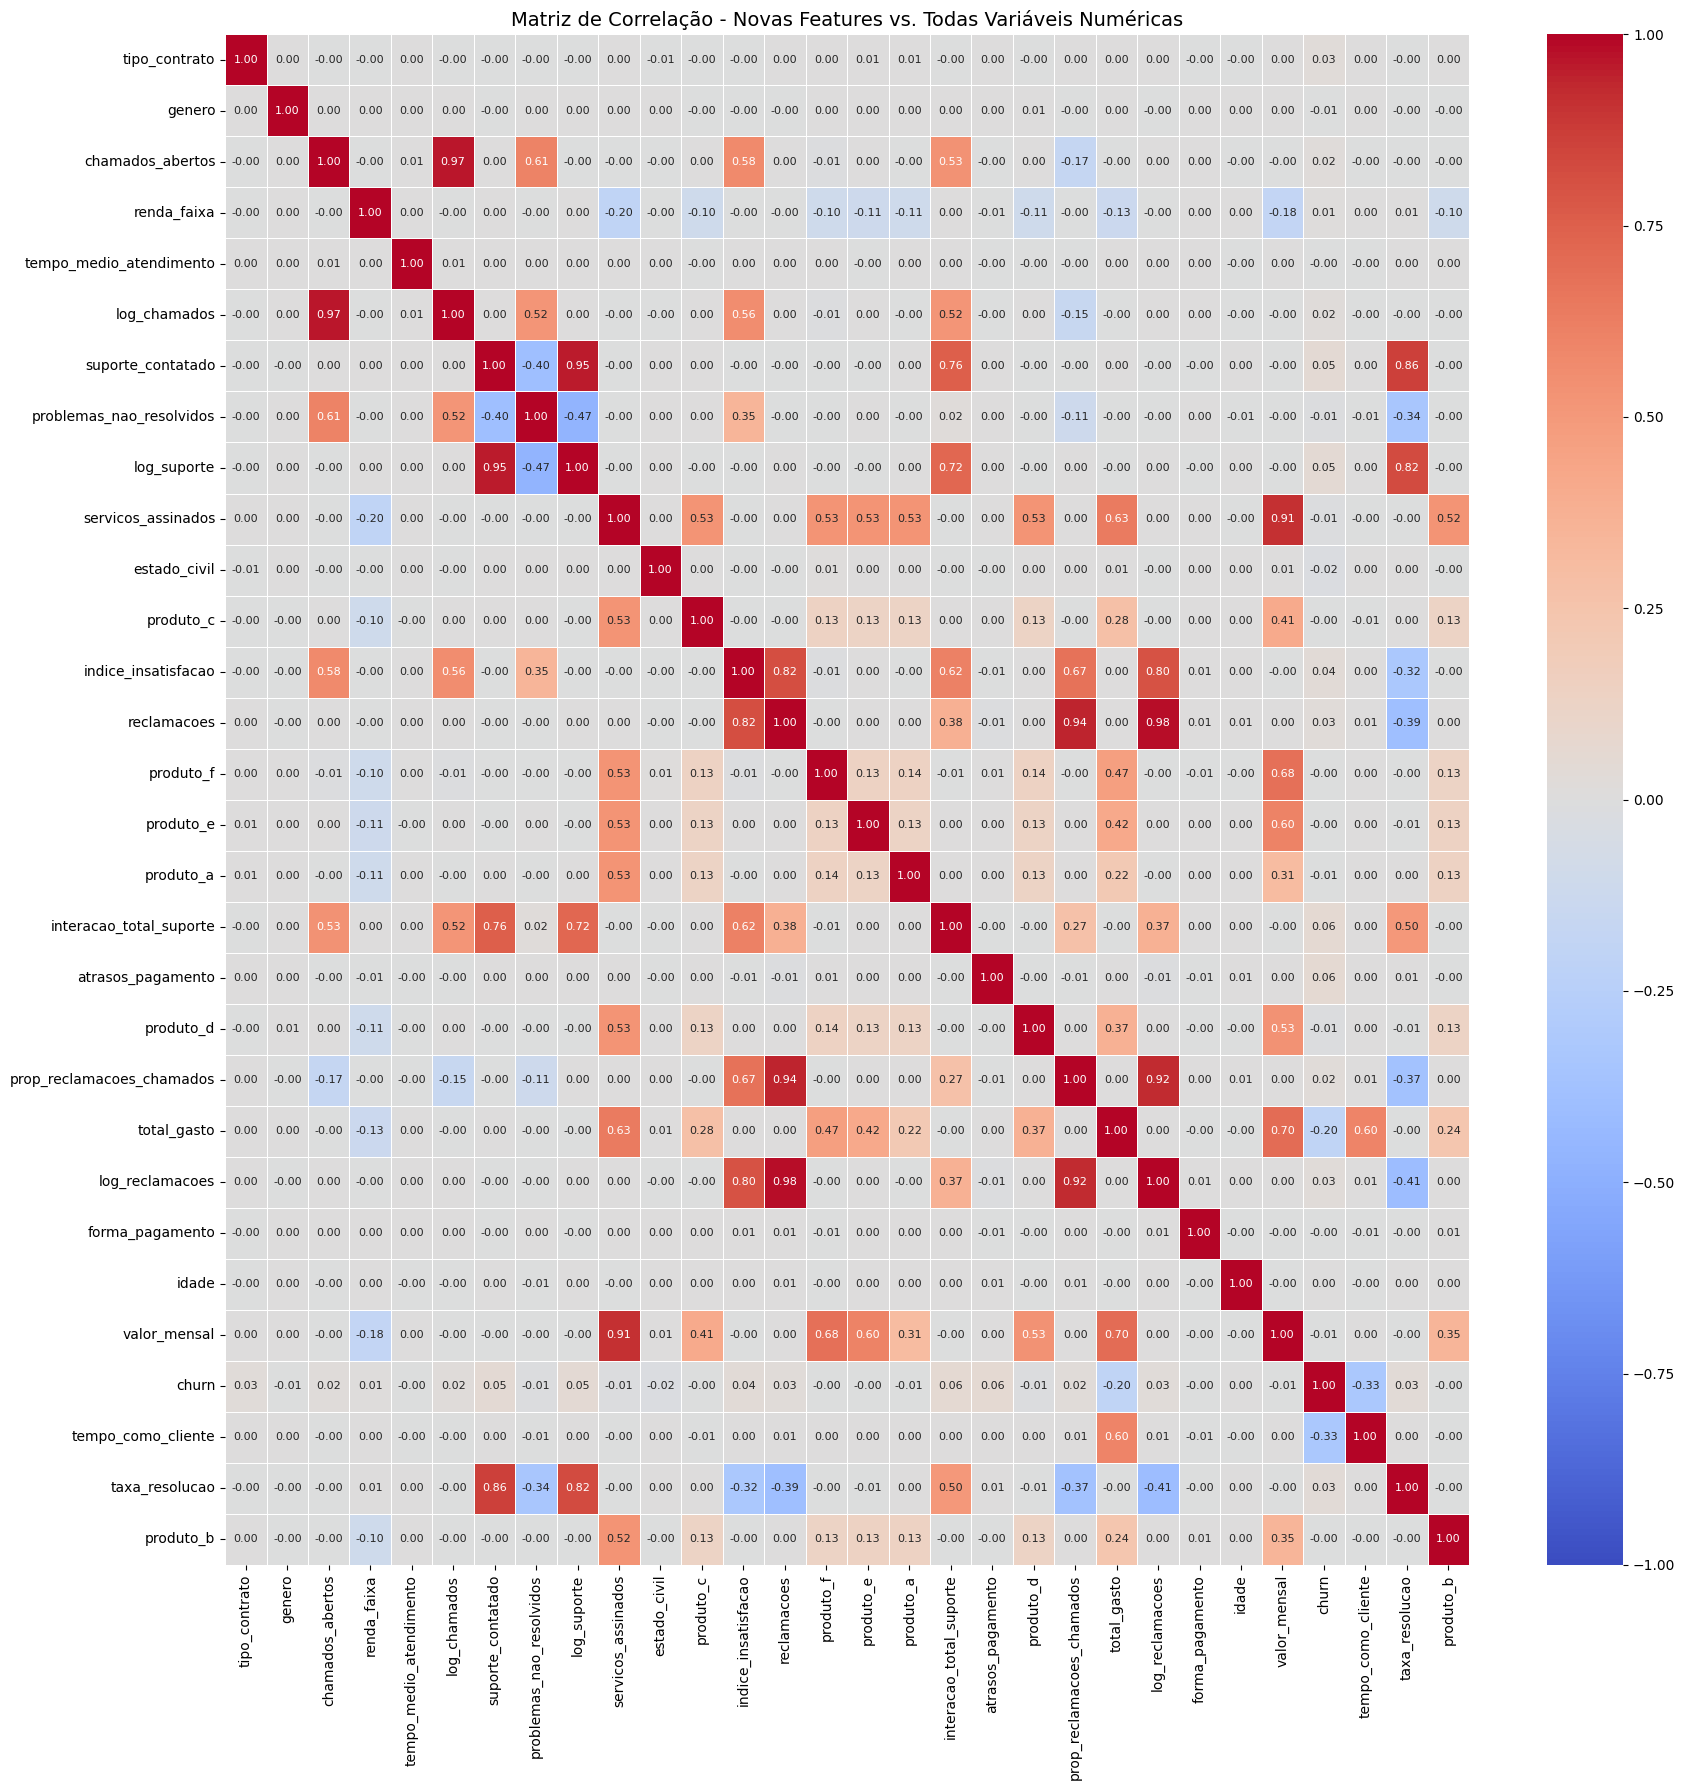

C:\Users\Inteli\AppData\Local\Temp\ipykernel_41956\3669434269.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacao_ordenada.values, y=correlacao_ordenada.index, palette='viridis')


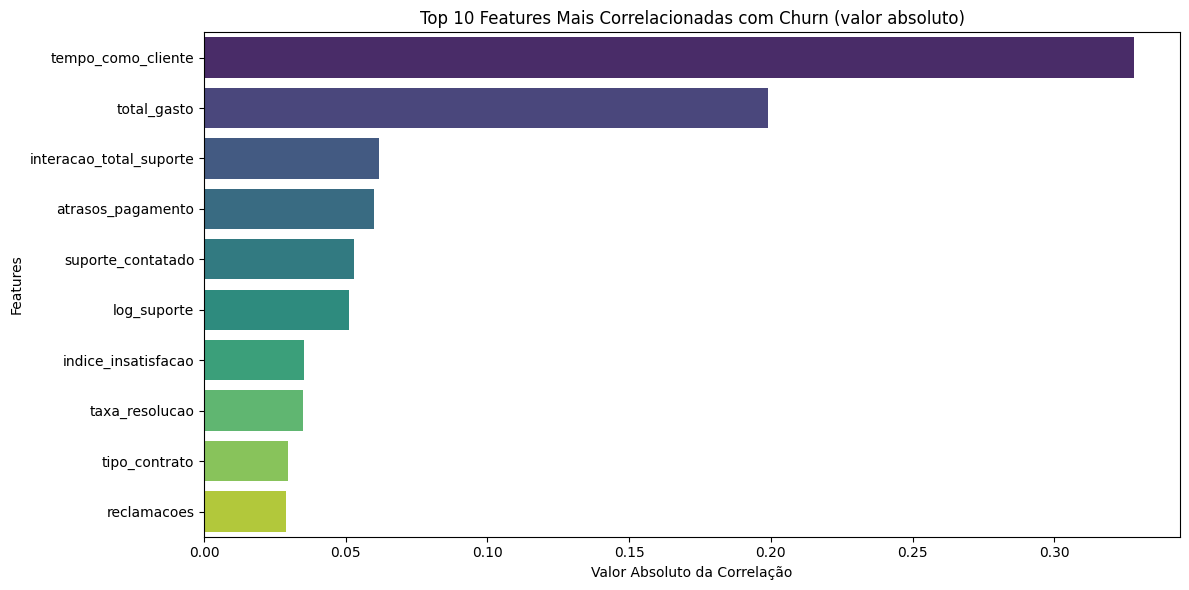

In [420]:


df_eng = df.copy()

df_eng['prop_reclamacoes_chamados'] = df_eng['reclamacoes'] / df_eng['chamados_abertos'].replace(0, 1)

df_eng['indice_insatisfacao'] = (df_eng['reclamacoes'] * 2 + df_eng['chamados_abertos']) / 3

df_eng['taxa_resolucao'] = df_eng['suporte_contatado'] / (df_eng['reclamacoes'] + 1)  # +1 para evitar divisão por zero

df_eng['interacao_total_suporte'] = df_eng['reclamacoes'] + df_eng['chamados_abertos'] + df_eng['suporte_contatado']

df_eng['problemas_nao_resolvidos'] = df_eng['chamados_abertos'] - df_eng['suporte_contatado']
df_eng['problemas_nao_resolvidos'] = df_eng['problemas_nao_resolvidos'].apply(lambda x: max(0, x))  # Não pode ser negativo

df_eng['log_reclamacoes'] = np.log1p(df_eng['reclamacoes'])
df_eng['log_chamados'] = np.log1p(df_eng['chamados_abertos'])
df_eng['log_suporte'] = np.log1p(df_eng['suporte_contatado'])

if 'tempo_contrato' in df_eng.columns:
    df_eng['uso_suporte_rel_tempo'] = df_eng['interacao_total_suporte'] / df_eng['tempo_contrato'].replace(0, 1)
    df_eng['reclamacoes_por_mes'] = df_eng['reclamacoes'] / df_eng['tempo_contrato'].replace(0, 1) * 12


features_novas = [
    'prop_reclamacoes_chamados', 
    'indice_insatisfacao', 
    'taxa_resolucao', 
    'interacao_total_suporte',
    'problemas_nao_resolvidos',
    'log_reclamacoes',
    'log_chamados',
    'log_suporte'
]

if 'tempo_contrato' in df_eng.columns:
    features_novas.extend(['uso_suporte_rel_tempo', 'reclamacoes_por_mes'])

features_para_analise = features_novas + ['churn']

correlacao_com_churn = df_eng[features_para_analise].corr()['churn'].sort_values(ascending=False)
print("Correlação das novas features com churn:")
print(correlacao_com_churn)
print("\n")

colunas_numericas = df_eng.select_dtypes(include=['number']).columns
correlacao_completa = df_eng[list(set(features_novas + list(colunas_numericas)))].corr()

n_colunas = len(correlacao_completa)
tamanho_figura = max(16, n_colunas * 0.6)

plt.figure(figsize=(tamanho_figura, tamanho_figura))

sns.heatmap(
    correlacao_completa, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8 if n_colunas > 15 else 10}
)

plt.title('Matriz de Correlação - Novas Features vs. Todas Variáveis Numéricas', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
correlacao_ordenada = correlacao_completa['churn'].drop('churn').abs().sort_values(ascending=False).head(10)
sns.barplot(x=correlacao_ordenada.values, y=correlacao_ordenada.index, palette='viridis')
plt.title('Top 10 Features Mais Correlacionadas com Churn (valor absoluto)')
plt.xlabel('Valor Absoluto da Correlação')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [421]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Definir X e y com o novo dataframe que inclui as features criadas
X = df_eng.drop('churn', axis=1)
y = df_eng['churn']

# Identificar e codificar colunas categóricas
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.74      0.88      0.81     19339
           1       0.63      0.40      0.49      9908

    accuracy                           0.72     29247
   macro avg       0.69      0.64      0.65     29247
weighted avg       0.70      0.72      0.70     29247

ROC-AUC: 0.6908011459186343


Encontrar melhores parâmetros através de Grid Search

In [422]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}


In [423]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,           
    n_jobs=-1,     
    verbose=2,
    scoring='accuracy' 
)


In [424]:
grid_search.fit(X_train, y_train)


print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Melhor score na validação cruzada:", grid_search.best_score_)


Fitting 3 folds for each of 216 candidates, totalling 648 fits


c:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
324 fits failed out of a total of 648.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
54 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Python312\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Python312\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "c:\Python312\Lib\site-packages\sklearn\utils\_param_validation.py", line 98, in validate_

Melhores hiperparâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Melhor score na validação cruzada: 0.7261257351120838


Testagem de diferentes modelos

In [425]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=10,
    random_state=42
)

best_rf.fit(X_train, y_train)


y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.74      0.89      0.81     19339
           1       0.65      0.41      0.50      9908

    accuracy                           0.72     29247
   macro avg       0.70      0.65      0.65     29247
weighted avg       0.71      0.72      0.70     29247

ROC-AUC: 0.7004977725369693


In [426]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

print("Regressão Logística")
print(classification_report(y_test, y_pred_logreg))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))


Regressão Logística
              precision    recall  f1-score   support

           0       0.79      0.65      0.71     19339
           1       0.49      0.66      0.57      9908

    accuracy                           0.66     29247
   macro avg       0.64      0.66      0.64     29247
weighted avg       0.69      0.66      0.66     29247

ROC-AUC: 0.7066397850242396


c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [427]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum()/(y_train == 1).sum(),  # balanceamento
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


c:\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [06:40:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
              precision    recall  f1-score   support

           0       0.77      0.78      0.77     19339
           1       0.56      0.55      0.55      9908

    accuracy                           0.70     29247
   macro avg       0.67      0.66      0.66     29247
weighted avg       0.70      0.70      0.70     29247

ROC-AUC: 0.6956901315151255


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_treino = df
df_desafio = pd.read_csv('desafio.csv')


df_eng_treino = df_treino.copy()

df_eng_treino['prop_reclamacoes_chamados'] = df_eng_treino['reclamacoes'] / df_eng_treino['chamados_abertos'].replace(0, 1)
df_eng_treino['indice_insatisfacao'] = (df_eng_treino['reclamacoes'] * 2 + df_eng_treino['chamados_abertos']) / 3
df_eng_treino['taxa_resolucao'] = df_eng_treino['suporte_contatado'] / (df_eng_treino['reclamacoes'] + 1)
df_eng_treino['interacao_total_suporte'] = df_eng_treino['reclamacoes'] + df_eng_treino['chamados_abertos'] + df_eng_treino['suporte_contatado']
df_eng_treino['problemas_nao_resolvidos'] = (df_eng_treino['chamados_abertos'] - df_eng_treino['suporte_contatado']).clip(lower=0)
df_eng_treino['log_reclamacoes'] = np.log1p(df_eng_treino['reclamacoes'])
df_eng_treino['log_chamados'] = np.log1p(df_eng_treino['chamados_abertos'])
df_eng_treino['log_suporte'] = np.log1p(df_eng_treino['suporte_contatado'])

if 'tempo_contrato' in df_eng_treino.columns:
    df_eng_treino['uso_suporte_rel_tempo'] = df_eng_treino['interacao_total_suporte'] / df_eng_treino['tempo_contrato'].replace(0, 1)
    df_eng_treino['reclamacoes_por_mes'] = df_eng_treino['reclamacoes'] / df_eng_treino['tempo_contrato'].replace(0, 1) * 12
if 'estado_civil' in df_eng_treino.columns:
    le_estado_civil = LabelEncoder()
    df_eng_treino['estado_civil'] = le_estado_civil.fit_transform(df_eng_treino['estado_civil'])

if 'forma_pagamento' in df_eng_treino.columns:
    le_forma_pagamento = LabelEncoder()
    df_eng_treino['forma_pagamento'] = le_forma_pagamento.fit_transform(df_eng_treino['forma_pagamento'])

if 'tipo_contrato' in df_eng_treino.columns:
    le_tipo_contrato = LabelEncoder()
    df_eng_treino['tipo_contrato'] = le_tipo_contrato.fit_transform(df_eng_treino['tipo_contrato'])

if 'genero' in df_eng_treino.columns:
    le_genero = LabelEncoder()
    df_eng_treino['genero'] = le_genero.fit_transform(df_eng_treino['genero'])
    
if 'renda_faixa' in df_eng_treino.columns:
    faixas_ordenadas = ['0-1000', '1000-5000', '5000-10000', '10000-50000', '50000-100000']
    df_eng_treino['renda_faixa'] = pd.Categorical(df_eng_treino['renda_faixa'], categories=faixas_ordenadas, ordered=True)
    df_eng_treino['renda_faixa'] = df_eng_treino['renda_faixa'].cat.codes
    
if 'idade' in df_eng_treino.columns:
    df_eng_treino = df_eng_treino[df_eng_treino['idade'] >= 18]
    
    bins = [17, 30, 50, 70, float('inf')]
    labels = [1, 2, 3, 4]
    df_eng_treino['idade'] = pd.cut(df_eng_treino['idade'], bins=bins, labels=labels)
    df_eng_treino['idade'] = df_eng_treino['idade'].astype(int)
    
if 'produtos_assinados' in df_eng_treino.columns:
    produtos = ['Produto A', 'Produto B', 'Produto C', 'Produto D', 'Produto E', 'Produto F']
    df_eng_treino['produtos_assinados'] = df_eng_treino['produtos_assinados'].astype(str)
    
    for produto in produtos:
        coluna = f"produto_{produto[-1].lower()}"
        df_eng_treino[coluna] = df_eng_treino['produtos_assinados'].apply(lambda x: 1 if produto in x else 0)
    
    df_eng_treino.drop(columns=['produtos_assinados'], inplace=True)
features_treino = df_eng_treino.select_dtypes(include=['float64', 'int64']).columns.tolist()

if 'churn' in features_treino:
    features_treino.remove('churn')
    
if 'id_cliente' in features_treino:
    features_treino.remove('id_cliente')

print(f"Features usadas no treino: {features_treino}")

X_treino = df_eng_treino[features_treino]
y_treino = df_eng_treino['churn']
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=10,
    random_state=42
)



In [ ]:
best_rf.fit(X_treino_scaled, y_treino)
df_eng_desafio = df_desafio.copy()
df_eng_desafio['prop_reclamacoes_chamados'] = df_eng_desafio['reclamacoes'] / df_eng_desafio['chamados_abertos'].replace(0, 1)
df_eng_desafio['indice_insatisfacao'] = (df_eng_desafio['reclamacoes'] * 2 + df_eng_desafio['chamados_abertos']) / 3
df_eng_desafio['taxa_resolucao'] = df_eng_desafio['suporte_contatado'] / (df_eng_desafio['reclamacoes'] + 1)
df_eng_desafio['interacao_total_suporte'] = df_eng_desafio['reclamacoes'] + df_eng_desafio['chamados_abertos'] + df_eng_desafio['suporte_contatado']
df_eng_desafio['problemas_nao_resolvidos'] = (df_eng_desafio['chamados_abertos'] - df_eng_desafio['suporte_contatado']).clip(lower=0)
df_eng_desafio['log_reclamacoes'] = np.log1p(df_eng_desafio['reclamacoes'])
df_eng_desafio['log_chamados'] = np.log1p(df_eng_desafio['chamados_abertos'])
df_eng_desafio['log_suporte'] = np.log1p(df_eng_desafio['suporte_contatado'])

if 'tempo_contrato' in df_eng_desafio.columns:
    df_eng_desafio['uso_suporte_rel_tempo'] = df_eng_desafio['interacao_total_suporte'] / df_eng_desafio['tempo_contrato'].replace(0, 1)
    df_eng_desafio['reclamacoes_por_mes'] = df_eng_desafio['reclamacoes'] / df_eng_desafio['tempo_contrato'].replace(0, 1) * 12
    
if 'estado_civil' in df_eng_desafio.columns and 'estado_civil' in df_eng_treino.columns:
    try:
        df_eng_desafio['estado_civil'] = le_estado_civil.transform(df_eng_desafio['estado_civil'])
    except:
        df_eng_desafio['estado_civil'] = LabelEncoder().fit_transform(df_eng_desafio['estado_civil'])

if 'forma_pagamento' in df_eng_desafio.columns and 'forma_pagamento' in df_eng_treino.columns:
    try:
        df_eng_desafio['forma_pagamento'] = le_forma_pagamento.transform(df_eng_desafio['forma_pagamento'])
    except:
        df_eng_desafio['forma_pagamento'] = LabelEncoder().fit_transform(df_eng_desafio['forma_pagamento'])

if 'tipo_contrato' in df_eng_desafio.columns and 'tipo_contrato' in df_eng_treino.columns:
    try:
        df_eng_desafio['tipo_contrato'] = le_tipo_contrato.transform(df_eng_desafio['tipo_contrato'])
    except:
        df_eng_desafio['tipo_contrato'] = LabelEncoder().fit_transform(df_eng_desafio['tipo_contrato'])

if 'genero' in df_eng_desafio.columns and 'genero' in df_eng_treino.columns:
    try:
        df_eng_desafio['genero'] = le_genero.transform(df_eng_desafio['genero'])
    except:
        df_eng_desafio['genero'] = LabelEncoder().fit_transform(df_eng_desafio['genero'])
        
if 'renda_faixa' in df_eng_desafio.columns and 'renda_faixa' in df_eng_treino.columns:
    faixas_ordenadas = ['0-1000', '1000-5000', '5000-10000', '10000-50000', '50000-100000']
    df_eng_desafio['renda_faixa'] = pd.Categorical(df_eng_desafio['renda_faixa'], categories=faixas_ordenadas, ordered=True)
    df_eng_desafio['renda_faixa'] = df_eng_desafio['renda_faixa'].cat.codes
    
if 'idade' in df_eng_desafio.columns and 'idade' in df_eng_treino.columns:
    df_eng_desafio = df_eng_desafio[df_eng_desafio['idade'] >= 18]
    
    bins = [17, 30, 50, 70, float('inf')]
    labels = [1, 2, 3, 4]
    df_eng_desafio['idade'] = pd.cut(df_eng_desafio['idade'], bins=bins, labels=labels)
    df_eng_desafio['idade'] = df_eng_desafio['idade'].astype(int)
    
if 'produtos_assinados' in df_eng_desafio.columns:
    produtos = ['Produto A', 'Produto B', 'Produto C', 'Produto D', 'Produto E', 'Produto F']
    df_eng_desafio['produtos_assinados'] = df_eng_desafio['produtos_assinados'].astype(str)
    
    for produto in produtos:
        coluna = f"produto_{produto[-1].lower()}"
        df_eng_desafio[coluna] = df_eng_desafio['produtos_assinados'].apply(lambda x: 1 if produto in x else 0)
    
    df_eng_desafio.drop(columns=['produtos_assinados'], inplace=True)

for feature in features_treino:
    if feature not in df_eng_desafio.columns:
        print(f"Feature {feature} está no conjunto de treino mas não no desafio. Adicionando com zeros.")
        df_eng_desafio[feature] = 0

X_desafio = df_eng_desafio[features_treino]
print(f"Shape de X_desafio: {X_desafio.shape}")

X_desafio_scaled = scaler.transform(X_desafio)

In [ ]:


predicoes = best_rf.predict(X_desafio_scaled)

df_resultado = df_desafio[['id_cliente']].copy()
df_resultado['churn'] = predicoes

df_resultado.to_csv('resultado_yasmin_minario.csv', index=False)

print("arquivo 'resultado.csv' criado!")
print(f"Total de clientes no resultado: {len(df_resultado)}")
print(f"Distribuição de churn: {df_resultado['churn'].value_counts().to_dict()}")